In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Загрузка набора данных
df = pd.read_csv('bike.csv')

df['high_demand'] = np.where(df['cnt'] >= 50, 1, 0)
df['high_demand'] = df['high_demand'].astype('category')

# Преобразуем нужные столбцы в категориальные данныеи
categorical_columns = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
for col in categorical_columns:
    df[col] = df[col].astype('category')

# Удаляем целевую переменную из X
y = df['high_demand']  # Целевая переменная
X = df.drop(['high_demand', 'cnt', 'dteday'], axis=1)  # Удаляем лишние столбцы


In [2]:
# Создаем копию данных
category_columns: list[str] = X.select_dtypes(include=['category']).columns # собираем колонки помеченные как category

# Применяем One-Hot Encoding
X = pd.get_dummies(X, columns=category_columns,drop_first=True) # drop_first=True позволяет избежать мультиколлинеарности, удаляя первый уровень категориальной переменной.


In [3]:
from sklearn.utils import resample

# Объединяем X и y для удобства
data = pd.concat([X, y], axis=1)

# Разделяем на классы
majority = data[data['high_demand'] == 0]
minority = data[data['high_demand'] == 1]

# Уменьшаем количество экземпляров класса 1
minority_downsampled = resample(minority,
                                replace=False,
                                n_samples=int(len(majority)*0.1),
                                random_state=42)

# Объединяем обратно
data_disbalanced = pd.concat([majority, minority_downsampled])

# Новые X и y
X_disbalanced = data_disbalanced.drop('high_demand', axis=1)
y_disbalanced = data_disbalanced['high_demand']

In [4]:
print(y_disbalanced.value_counts())

high_demand
0    4821
1     482
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Разделяем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_disbalanced, y_disbalanced, test_size=0.3, random_state=42)

# Обучаем модель
model = LogisticRegression(penalty=None, solver='saga', max_iter=10000)
model.fit(X_train, y_train)

# Предсказания
y_pred = model.predict(X_test)

In [6]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9044626021370208

Classification Report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95      1439
           1       0.00      0.00      0.00       152

    accuracy                           0.90      1591
   macro avg       0.45      0.50      0.47      1591
weighted avg       0.82      0.90      0.86      1591



/opt/jupyterhub/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/jupyterhub/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/jupyterhub/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [7]:
unique, counts = np.unique(y_pred, return_counts=True) # получаем уникальные значения и их количество в предсказанных данных
dict(zip(unique, counts)) # данная ситуация называется переобучением. Модель очень хорошо обучилась на 0, настолько, что не может предсказать 1

{np.int64(0): np.int64(1591)}

In [8]:
# Уменьшаем количество экземпляров класса 0
majority_downsampled = resample(majority,
                                replace=True,
                                n_samples=len(minority),
                                random_state=42)

# Объединяем обратно
data_balanced = pd.concat([majority_downsampled, minority])

# Новые X и y
X_balanced = data_balanced.drop('high_demand', axis=1)
y_balanced = data_balanced['high_demand']

print(y_balanced.value_counts())



high_demand
0    12558
1    12558
Name: count, dtype: int64


In [9]:
# Разделяем данные
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(X_balanced, y_balanced, test_size=0.3, random_state=42)

# Обучаем модель
model_balanced = LogisticRegression(penalty=None, solver='saga', max_iter=10000)
model_balanced.fit(X_train_bal, y_train_bal)

# Предсказания
y_pred_bal = model_balanced.predict(X_test_bal)

In [10]:
print("Accuracy:", accuracy_score(y_test_bal, y_pred_bal))
print("\nClassification Report:\n", classification_report(y_test_bal, y_pred_bal))

Accuracy: 0.589648307896483

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.30      0.43      3823
           1       0.55      0.89      0.68      3712

    accuracy                           0.59      7535
   macro avg       0.64      0.59      0.55      7535
weighted avg       0.64      0.59      0.55      7535



In [11]:
unique, counts = np.unique(y_pred_bal, return_counts=True) # получаем уникальные значения и их количество в предсказанных данных

dict(zip(unique, counts))

{np.int64(0): np.int64(1575), np.int64(1): np.int64(5960)}

In [12]:
# Выбираем числовые признаки
numeric_features = X_balanced.select_dtypes(include=['float64']).columns.tolist()

# Инициализируем scaler
scaler = MinMaxScaler()

# Применяем нормализацию
X_balanced[numeric_features] = scaler.fit_transform(X_balanced[numeric_features])

In [13]:
# Разделяем данные
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(X_balanced, y_balanced, test_size=0.3, random_state=42)

# Обучаем модель
model_balanced = LogisticRegression(penalty=None, solver='saga', max_iter=10000)
model_balanced.fit(X_train_bal, y_train_bal)

# Предсказания
y_pred_bal = model_balanced.predict(X_test_bal)


In [14]:
print("Accuracy:", accuracy_score(y_test_bal, y_pred_bal))
print("\nClassification Report:\n", classification_report(y_test_bal, y_pred_bal))

Accuracy: 0.5903118779031188

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.30      0.43      3823
           1       0.55      0.89      0.68      3712

    accuracy                           0.59      7535
   macro avg       0.64      0.59      0.55      7535
weighted avg       0.64      0.59      0.55      7535



2 Метрики качества классификаци

In [15]:

# Разделяем данные
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(X_balanced, y_balanced, test_size=0.3, random_state=42)

# Обучаем модель
model_balanced = LogisticRegression(penalty=None, solver='saga', max_iter=10000)
model_balanced.fit(X_train_bal, y_train_bal)

# Предсказания
y_pred_bal = model_balanced.predict(X_test_bal)

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
# Вычисляем матрицу ошибок (TP, FP, TN, FN)
conf_matrix = confusion_matrix(y_test_bal, y_pred_bal)
tn, fp, fn, tp = conf_matrix.ravel()

# Рассчитываем метрики
accuracy = accuracy_score(y_test_bal, y_pred_bal)
precision = precision_score(y_test_bal, y_pred_bal)
recall = recall_score(y_test_bal, y_pred_bal)
f1 = f1_score(y_test_bal, y_pred_bal)
roc_auc = roc_auc_score(y_test_bal, y_pred_bal)

# Генерируем classification_report
class_report = classification_report(y_test_bal, y_pred_bal, output_dict=True)

# Формируем результаты для наглядного вывода
results = {
    "True Negatives (TN)": tn,
    "False Positives (FP)": fp,
    "False Negatives (FN)": fn,
    "True Positives (TP)": tp,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "ROC-AUC": roc_auc,
}

# Округляем все значения в словаре до двух знаков после запятой и возвращаем в виде dict.items()
rounded_items = {k: round(v, 2) for k, v in results.items()}

⏰ оцениваем метрики и объясняем результат (без ChatGPT)

In [17]:
print(classification_report(y_test_bal, y_pred_bal))

              precision    recall  f1-score   support

           0       0.73      0.30      0.43      3823
           1       0.55      0.89      0.68      3712

    accuracy                           0.59      7535
   macro avg       0.64      0.59      0.55      7535
weighted avg       0.64      0.59      0.55      7535



In [18]:
conf_matrix # Матрица
# TN FP
# FN TP

array([[1153, 2670],
       [ 417, 3295]])

In [19]:
rounded_items


{'True Negatives (TN)': np.int64(1153),
 'False Positives (FP)': np.int64(2670),
 'False Negatives (FN)': np.int64(417),
 'True Positives (TP)': np.int64(3295),
 'Accuracy': 0.59,
 'Precision': np.float64(0.55),
 'Recall': np.float64(0.89),
 'F1-score': np.float64(0.68),
 'ROC-AUC': np.float64(0.59)}

3. Задача мультиклассовой классфикации

In [20]:
# Создаем копию данных
category_columns: list[str] = X.select_dtypes(include=['category']).columns # собираем колонки помеченные как category

# Применяем One-Hot Encoding
X = pd.get_dummies(X, columns=category_columns,drop_first=True) # drop_first=True позволяет избежать мультиколлинеарности, удаляя первый уровень категориальной переменной.


In [21]:
X

,instant,temp,atemp,hum,windspeed,season_2,season_3,season_4,yr_1,mnth_2,...,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_1,weathersit_2,weathersit_3,weathersit_4
0,1,0.24,0.2879,0.81,0.0000,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,2,0.22,0.2727,0.80,0.0000,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,3,0.22,0.2727,0.80,0.0000,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,4,0.24,0.2879,0.75,0.0000,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,5,0.24,0.2879,0.75,0.0000,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,0.26,0.2576,0.60,0.1642,False,False,False,True,False,...,True,False,False,False,False,False,True,True,False,False
17375,17376,0.26,0.2576,0.60,0.1642,False,False,False,True,False,...,True,False,False,False,False,False,True,True,False,False
17376,17377,0.26,0.2576,0.60,0.1642,False,False,False,True,False,...,True,False,False,False,False,False,True,False,False,False
17377,17378,0.26,0.2727,0.56,0.1343,False,False,False,True,False,...,True,False,False,False,False,False,True,False,False,False


In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Разделяем данные
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X, y, test_size=0.3, random_state=42)

# Определяем категориальные и числовые признаки
categorical_features = X_train_multi.select_dtypes(include=['object']).columns.tolist()
numerical_features = X_train_multi.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ],
    remainder='drop'
)

# Создаем Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, max_depth=10))
])

# Обучаем модель
pipeline.fit(X_train_multi, y_train_multi)

# Предсказания
y_pred_multi = pipeline.predict(X_test_multi)

# Извлекаем модель дерева решений из pipeline
tree_model = pipeline.named_steps['classifier']

# Получаем имена признаков после обработки
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out(categorical_features + numerical_features)

In [23]:
accuracy_score(y_test_multi, y_pred_multi)

0.9223245109321059

In [24]:
from sklearn.metrics import balanced_accuracy_score
balanced_accuracy_score(y_test_multi, y_pred_multi)

np.float64(0.8679644718247659)

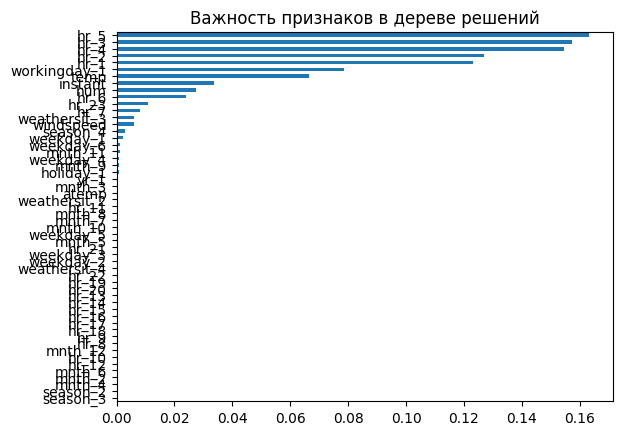

In [25]:
import matplotlib.pyplot as plt
feature_importances = pd.Series(tree_model.feature_importances_, index=X.columns)
feature_importances.sort_values().plot(kind='barh')
plt.title('Важность признаков в дереве решений')
plt.show()

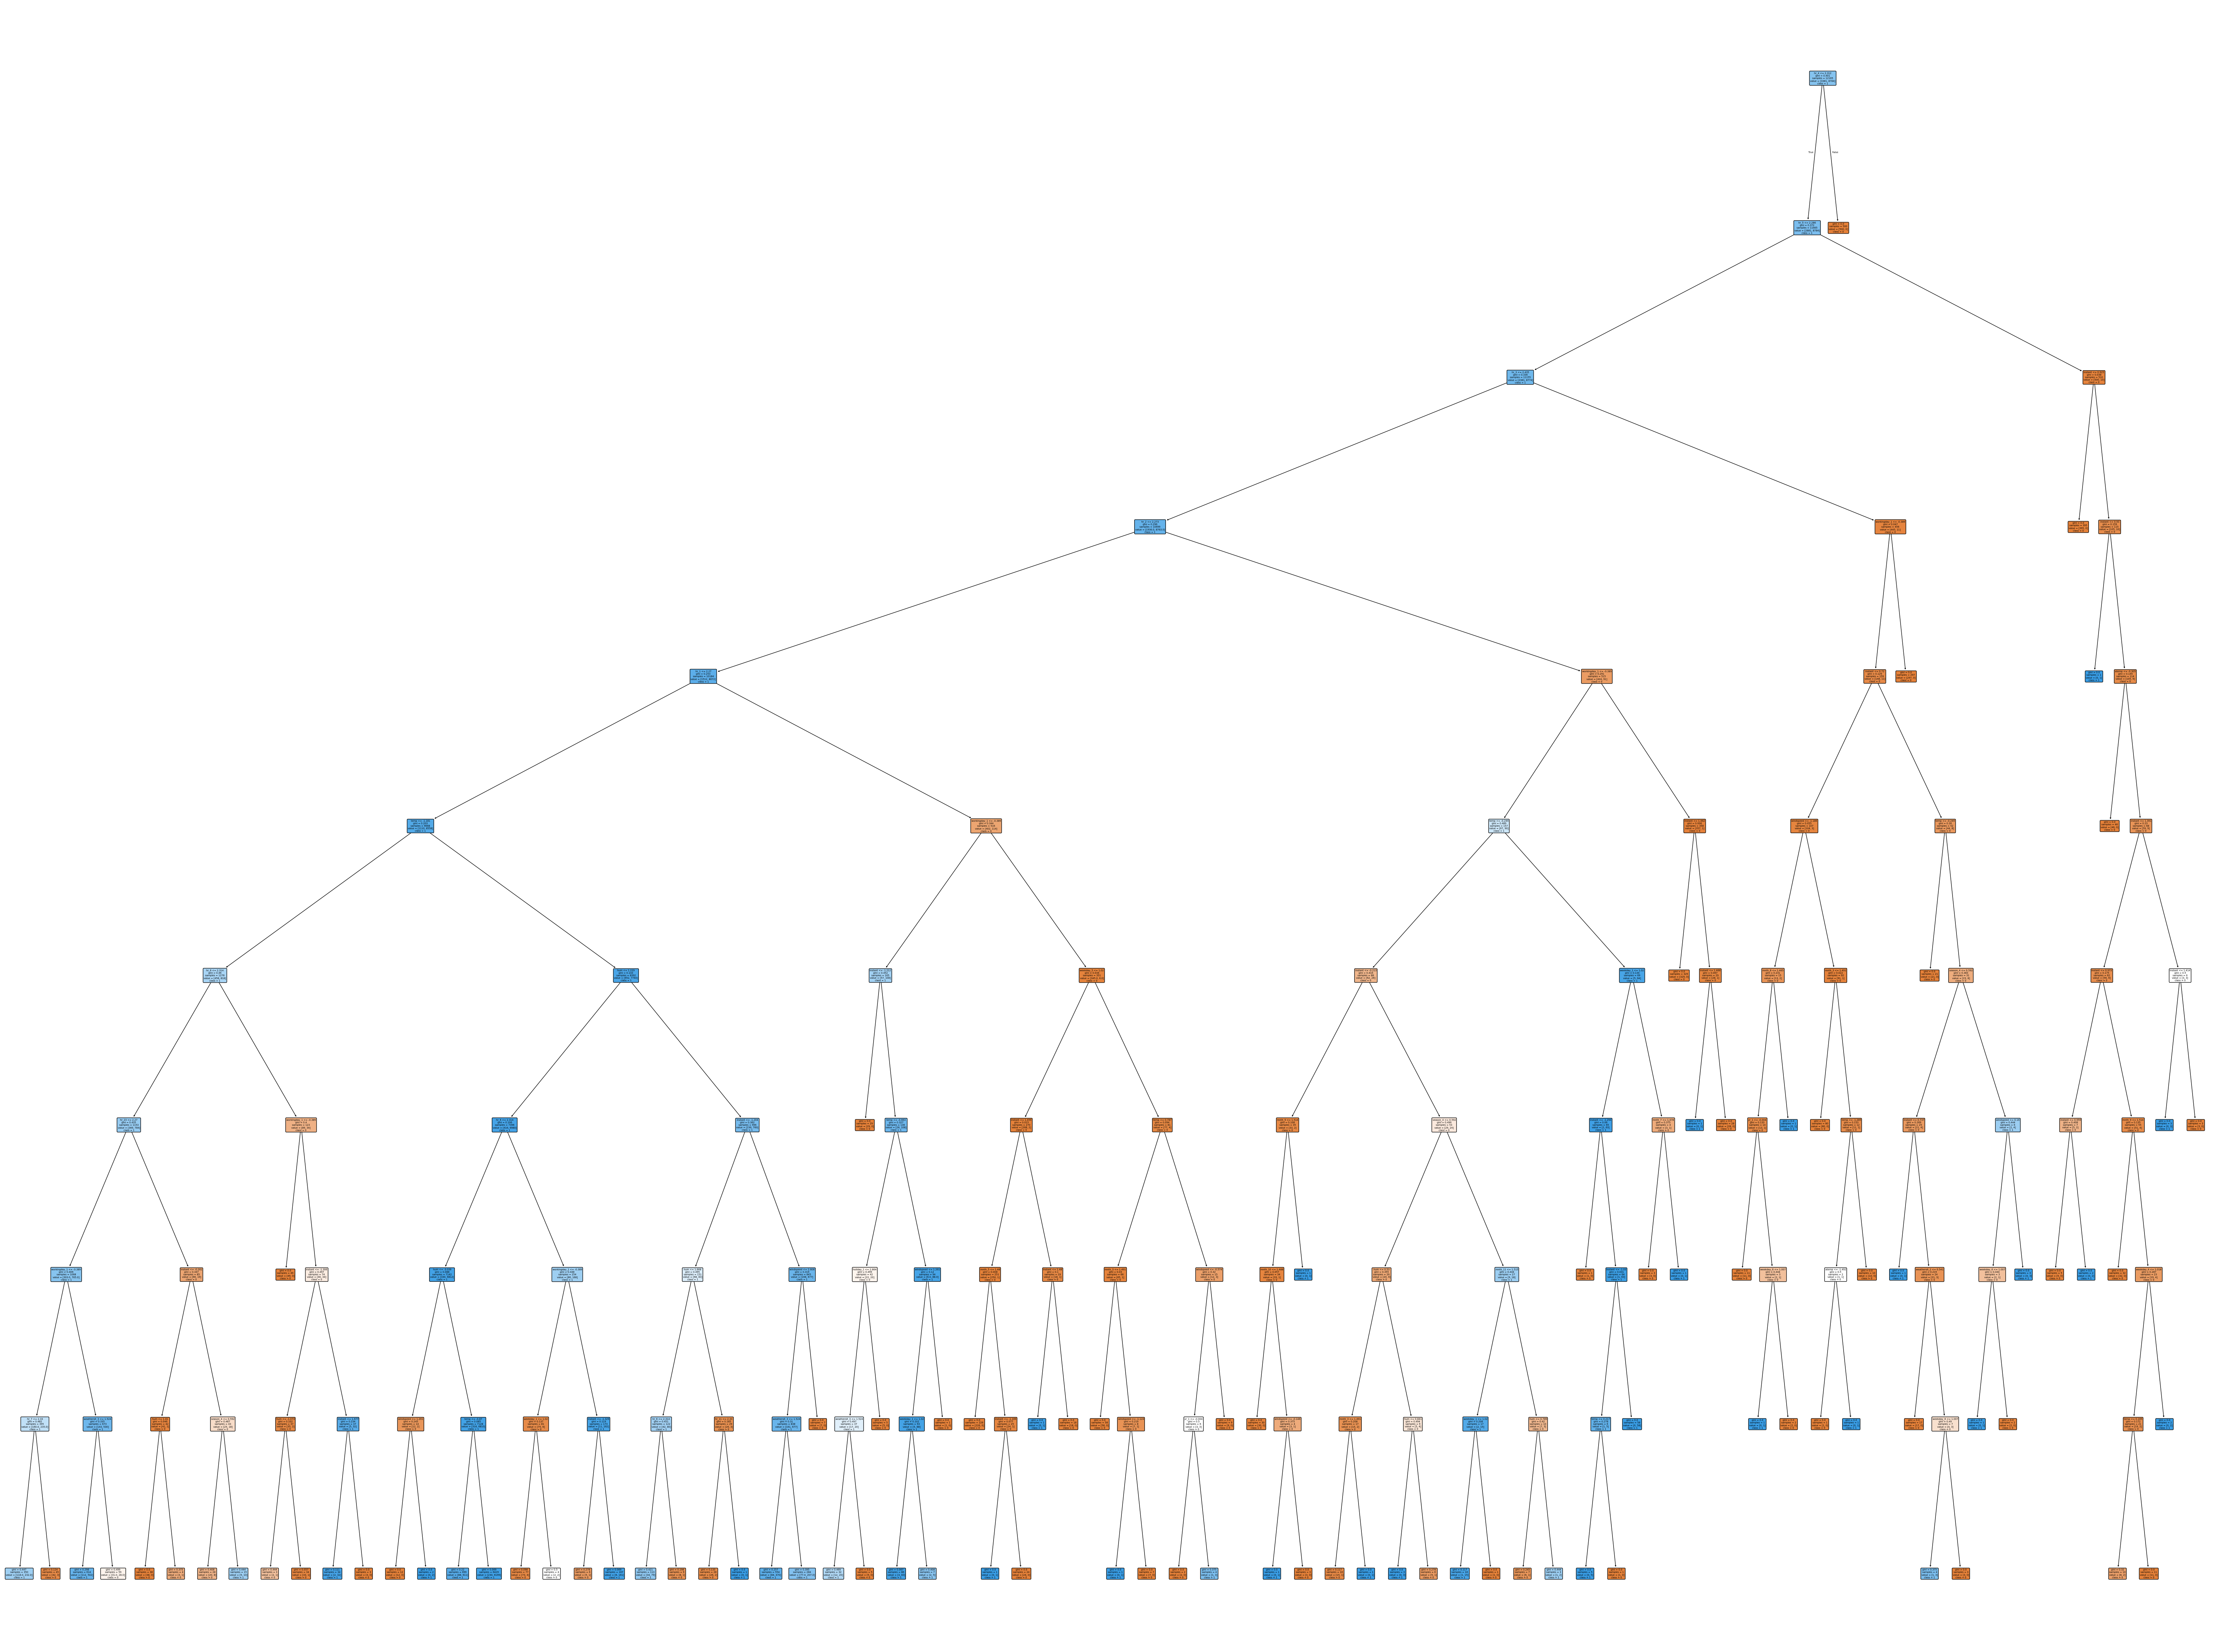

In [26]:
from sklearn.tree import plot_tree
# Визуализируем дерево решений
plt.figure(figsize=(80, 60))
plot_tree(tree_model, feature_names=X.columns, class_names=[str(item) for item in sorted(y.unique())], filled=True, rounded=True)
plt.show()